Kode itu dipakai buat manggil library yang dibutuhin. matplotlib.pyplot dipakai buat bikin dan nampilin grafik, numpy buat ngolah angka dan operasi matriks, dan inv dari numpy.linalg dipakai buat ngitung invers matriks, biasanya buat nyelesain persamaan regresi atau inversi linear.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import inv     

#Kode itu dipakai buat manggil library yang dibutuhin. matplotlib.pyplot dipakai buat bikin dan nampilin grafik, numpy buat ngolah angka dan operasi matriks, dan inv dari numpy.linalg dipakai buat ngitung invers matriks, biasanya buat nyelesain persamaan regresi atau inversi linear.

In [ ]:
z = [5,16,25,40,50,60,70,80,90,100]
T = [35.4,50.1,77.3,92.3,137.6,147,180.8,182.7,188.5,223.2]

#Mendeskripsikan data yang diberikan, yaitu dua list z dan T. 

In [ ]:
G = np.zeros((len(z),2))

for i in range(len(z)):
    G[i,0] = 1
    G[i,1] = z[i]

d = np.reshape(T, (len(T),1)) #Buat data T jadi masing masing ex : [35.4] [77.3]*

#membuat matriks G yang terdiri dari dua kolom, dimana kolom pertama diisi dengan angka 1 (untuk intercept) dan kolom kedua diisi dengan nilai-nilai dari list z. Kemudian, data T diubah menjadi bentuk matriks kolom (reshape) agar bisa digunakan dalam perhitungan regresi linear.

In [ ]:
#m = np.mat(inv(G.T @ G) @ G.T @ d)
m =  np.asmatrix(inv(np.asmatrix(G.transpose())*np.asmatrix(G)))*np.asmatrix(G.transpose())*np.asmatrix(d)
m = m.tolist()

#menghitung parameter regresi linear menggunakan metode least squares. Rumusnya adalah m = (G^T G)^(-1) G^T d, dimana G^T adalah transpose dari matriks G, dan (G^T G)^(-1) adalah invers dari matriks hasil perkalian G^T dan G. Hasilnya disimpan dalam variabel m, yang kemudian diubah menjadi list untuk memudahkan akses ke nilai-nilai parameter regresi.

In [ ]:
a0 = m[0][0]
a1 = m[1][0]

linear=[]
for i in range(len(z)):
    linear.append(a0+a1*z[i])

    #menggunakan parameter regresi yang telah dihitung (a0 dan a1) untuk membuat prediksi nilai T berdasarkan nilai z. Prediksi ini disimpan dalam list linear, dimana setiap elemen linear[i] dihitung sebagai a0 + a1 * z[i]. Ini menghasilkan garis regresi linear yang dapat digunakan untuk memprediksi nilai T untuk setiap nilai z.

In [ ]:
print(a0)
print(a1)

#menampilkan nilai dari a0 dan a1

25.280020266482765
1.981529472640248


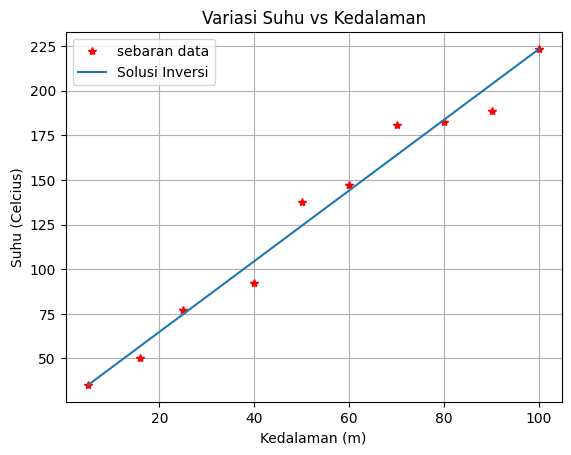

In [ ]:
plt.plot(z,T, 'r*', label='sebaran data')
plt.plot(z, linear, label='Solusi Inversi')
plt.grid()
plt.legend()
plt.xlabel('Kedalaman (m)')
plt.ylabel('Suhu (Celcius)')
plt.title('Variasi Suhu vs Kedalaman')
plt.show()

#membuat grafik yang menunjukkan sebaran data asli (z vs T) dengan tanda bintang merah, dan garis regresi linear (z vs linear) yang merupakan solusi inversi.

MASALAH 2

In [ ]:
data = np.loadtxt('datayo.txt')

t = data[:,0]
h = data[:,1]

#membaca data dari file 'datayo.txt' menggunakan fungsi np.loadtxt, dan menyimpan kolom pertama ke dalam variabel t dan kolom kedua ke dalam variabel h.

In [ ]:
h0 = 5
d = np.reshape(h-h0, (len(h),1))

G = np.zeros((len(t),2))

for i in range(len(t)):
    G[i,0] = t[i]
    G[i,1] = t[i]**2 
#membuat matriks G untuk data t, dimana kolom pertama diisi dengan nilai t dan kolom kedua diisi dengan nilai t kuadrat. Data h diubah menjadi bentuk matriks kolom setelah dikurangi dengan h0, yang merupakan nilai awal atau baseline untuk perhitungan inversi.

In [ ]:
GT = G.transpose()
GTG = np.matmul(GT,G)
GTG_inv = inv(GTG)
GTd = np.matmul(GT,d)

m = np.matmul(GTG_inv, GTd)

m1 = m[0][0]
m2 = m[1][0]

V0 = m1
g = -2*m2

print(m1)
print(m2)

#menghitung parameter regresi untuk model kuadrat, dimana m1 adalah koefisien untuk t dan m2 adalah koefisien untuk t kuadrat. V0 diambil sebagai m1, dan g dihitung sebagai -2 kali m2. Nilai m1 dan m2 kemudian ditampilkan.

3.20036328105958
-0.8168238201034915


In [ ]:
h_model = []

for i in range(len(t)):
    h_model.append(h0 + m1*t[i] + m2*(t[i]**2))

#menggunakan parameter regresi yang telah dihitung untuk membuat prediksi nilai h berdasarkan nilai t. Prediksi ini disimpan dalam list h_model, dimana setiap elemen h_model[i] dihitung sebagai h0 + m1*t[i] + m2*(t[i]**2). Ini menghasilkan kurva regresi kuadrat yang dapat digunakan untuk memprediksi nilai h untuk setiap nilai t.

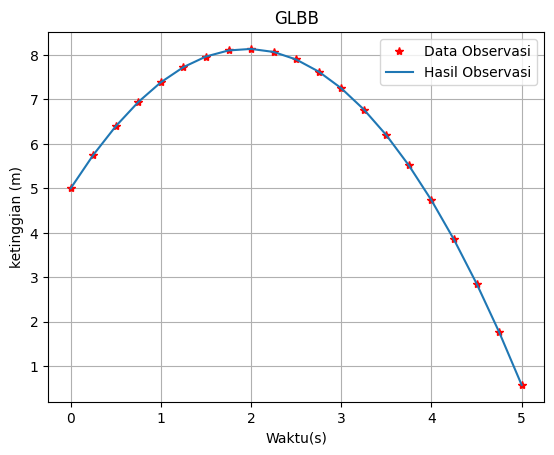

In [ ]:
plt.plot(t,h,'r*', label='Data Observasi')
plt.plot(t, h_model, label='Hasil Observasi')
plt.grid()
plt.legend()
plt.xlabel('Waktu(s)')
plt.ylabel('ketinggian (m)')
plt.title('GLBB')
plt.show()

#membuat grafik yang menunjukkan sebaran data asli (t vs h) dengan tanda bintang merah, dan kurva regresi kuadrat (t vs h_model) yang merupakan solusi inversi untuk model GLBB.